In [ ]:
# Install required packages
!pip install face_recognition numpy scikit-learn matplotlib pillow seaborn

print("✅ Packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=14c891b340869648f0a607f3d3ce481781ffa920b0388aa2fefe53ebcccced28
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models
✅ Packages installed successfully!


(125, 94, 3)
uint8
2 252


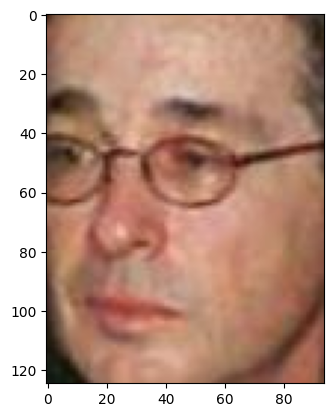

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

img = np.array(Image.open("dataset/building_2/Alvaro_Uribe/reference/ref_16.jpg"))

print(img.shape)
print(img.dtype)
print(img.min(), img.max())

plt.imshow(img)
plt.show()

In [ ]:
# =============================================================================
# DSTS - Distributed Multi-Building Surveillance System
# Complete Optimised Implementation
# Mohan et al. (IET Computer Vision, 2020) — 5 Buildings × 5 Occupants
# =============================================================================

# ========================= BLOCK 0: CONSTANTS ================================
import os, random, math, copy, json, pickle, threading, time
import numpy as np
import face_recognition
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image, ImageFilter, ImageEnhance
from sklearn.datasets import fetch_lfw_people
from dataclasses import dataclass, field
from typing import Dict, List, Optional
from datetime import datetime
from IPython.display import display

# ---------- dataset split ----------
IMAGES_PER_PERSON      = 40
REFERENCE_IMAGES       = 20
TEST_IMAGES            = 20
MIN_IMAGES_REQUIRED    = 30

# ---------- recognition ----------
#   FACE_MATCH_TOLERANCE : distance threshold for compare_faces (vote counting)
#   LAMBDA_SCALE         : λ in P(o|e) = exp(-λ × distance) × zone_decay
#                          paper uses λ = 5.0
#   MIN_VOTE_THRESHOLD   : minimum TRUE votes from compare_faces for a valid match
#                          paper observed minimum of 12 across experiments
FACE_MATCH_TOLERANCE   = 0.6
LAMBDA_SCALE           = 5.0
MIN_VOTE_THRESHOLD     = 12

# ---------- evaluation ----------
#   PROBABILITY_SUM_TOLERANCE : guard against division-by-zero in normalisation
PROBABILITY_SUM_TOLERANCE = 1e-6

# ---------- topology ----------
NUM_BUILDINGS          = 5
OCCUPANTS_PER_BUILDING = 5
TOTAL_OCCUPANTS        = NUM_BUILDINGS * OCCUPANTS_PER_BUILDING

# ---------- simulation ----------
#   NUM_TRAVERSALS × len(ZONE_ORDER) = events per person
#   4 × 5 = 20 events/person × 5 persons = 100 events/building × 5 = 500 total
NUM_TRAVERSALS = 4
ZONE_ORDER     = ['zT', 'z1', 'z2', 'z3', 'z4']

# ---------- paths ----------
DATASET_DIR  = "dataset"
ENCODING_DIR = "encodings"

os.makedirs(DATASET_DIR,  exist_ok=True)
os.makedirs(ENCODING_DIR, exist_ok=True)

random.seed(42)
np.random.seed(42)

print("=== DSTS Distributed System Initialized ===\n")



=== DSTS Distributed System Initialized ===



In [ ]:


# ========================= BLOCK 1: DATASET PREPARATION ======================

def load_lfw_dataset():
    print("Loading LFW dataset...")
    lfw = fetch_lfw_people(
        min_faces_per_person=MIN_IMAGES_REQUIRED,
        resize=1.0,
        color=True
    )
    print(f"Total images loaded   : {len(lfw.images)}")
    print(f"Total identities      : {len(lfw.target_names)}")
    return lfw


def group_images_by_person(lfw):
    """Keep only images where a face is detectable."""
    people_data   = {}
    total_checked = total_valid = total_failed = 0
    print("\nFiltering images with detectable faces...")

    for idx, target in enumerate(lfw.target):
        person_name = lfw.target_names[target]
        image       = lfw.images[idx]
        # LFW images may come as float [0,1] — normalise to uint8
        image = (image * 255).astype(np.uint8) if image.max() <= 1.0 \
                else image.astype(np.uint8)
        total_checked += 1
        try:
            if len(face_recognition.face_locations(image)) == 0:
                total_failed += 1
                continue
            people_data.setdefault(person_name, []).append(image)
            total_valid += 1
        except Exception:
            total_failed += 1

    print(f"Checked: {total_checked} | Valid: {total_valid} | Failed: {total_failed}")
    return people_data


def select_25_people(people_data):
    eligible = {n: imgs for n, imgs in people_data.items()
                if len(imgs) >= MIN_IMAGES_REQUIRED}
    chosen = random.sample(list(eligible.keys()), min(25, len(eligible)))
    return {n: eligible[n] for n in chosen}


def assign_to_buildings(selected_people):
    names = list(selected_people.keys())
    assignments = {}
    for b in range(NUM_BUILDINGS):
        bname = f"building_{b}"
        assignments[bname] = {}
        for name in names[b * OCCUPANTS_PER_BUILDING:(b + 1) * OCCUPANTS_PER_BUILDING]:
            imgs      = selected_people[name]
            ref       = imgs[:REFERENCE_IMAGES]
            remaining = imgs[REFERENCE_IMAGES:]
            test_orig = remaining[:TEST_IMAGES]
            # augment only if not enough original test images
            test_aug = []
            if len(test_orig) < TEST_IMAGES:
                needed = TEST_IMAGES - len(test_orig)
                for i in range(needed):
                    src = ref[i % len(ref)].copy()
                    aug = Image.fromarray(src)
                    aug = aug.filter(ImageFilter.GaussianBlur(radius=1))
                    aug = ImageEnhance.Brightness(aug).enhance(
                        random.uniform(0.8, 1.2))
                    test_aug.append(np.array(aug))
            assignments[bname][name] = {
                "reference": ref,
                "test":      test_orig + test_aug,
                "stats": {
                    "total_original_images": len(imgs),
                    "reference_original":    len(ref),
                    "test_original":         len(test_orig),
                    "test_augmented":        len(test_aug),
                }
            }
    return assignments


def save_dataset(assignments):
    for bname, occupants in assignments.items():
        for person_name, data in occupants.items():
            folder      = person_name.replace(" ", "_")
            person_path = os.path.join(DATASET_DIR, bname, folder)
            for split in ("reference", "test"):
                split_path = os.path.join(person_path, split)
                os.makedirs(split_path, exist_ok=True)
                prefix = "ref" if split == "reference" else "test"
                for i, img in enumerate(data[split]):
                    Image.fromarray(img.astype(np.uint8)).save(
                        os.path.join(split_path, f"{prefix}_{i}.jpg"))
    print(f"✅ Dataset saved to '{DATASET_DIR}'")


def prepare_dataset():
    lfw         = load_lfw_dataset()
    people_data = group_images_by_person(lfw)
    selected    = select_25_people(people_data)
    assignments = assign_to_buildings(selected)
    save_dataset(assignments)

    print("\n========== DATASET VERIFICATION ==========")
    total = 0
    for bname, occupants in assignments.items():
        print(f"\n{bname}\n" + "-" * 50)
        print(f"Occupants: {len(occupants)}")
        for person, data in occupants.items():
            s = data["stats"]
            print(f"  {person}")
            print(f"    Total Original : {s['total_original_images']}")
            print(f"    Reference      : {s['reference_original']}")
            print(f"    Test Original  : {s['test_original']}")
            print(f"    Test Augmented : {s['test_augmented']}")
            total += 1
    print(f"\nTotal People Assigned: {total}")
    return assignments

building_assignments = prepare_dataset()



Loading LFW dataset...
Total images loaded   : 2370
Total identities      : 34

Filtering images with detectable faces...
Checked: 2370 | Valid: 2243 | Failed: 127
✅ Dataset saved to 'dataset'

========== DATASET VERIFICATION ==========

building_0
--------------------------------------------------
Occupants: 5
  Tony Blair
    Total Original : 138
    Reference      : 20
    Test Original  : 20
    Test Augmented : 0
  Nestor Kirchner
    Total Original : 34
    Reference      : 20
    Test Original  : 14
    Test Augmented : 6
  George W Bush
    Total Original : 501
    Reference      : 20
    Test Original  : 20
    Test Augmented : 0
  John Negroponte
    Total Original : 31
    Reference      : 20
    Test Original  : 11
    Test Augmented : 9
  David Beckham
    Total Original : 31
    Reference      : 20
    Test Original  : 11
    Test Augmented : 9

building_1
--------------------------------------------------
Occupants: 5
  Gerhard Schroeder
    Total Original : 106
    Refe

In [ ]:

# ========================= BLOCK 2: FACE ENCODING DATABASE ===================

def _encode_image_file(image_path) -> Optional[np.ndarray]:
    """Return 128-d encoding for a single-face image, or None."""
    image = face_recognition.load_image_file(image_path)
    locs  = face_recognition.face_locations(image)
    if len(locs) == 0:
        print(f"  No face  : {image_path}")
        return None
    if len(locs) > 1:
        print(f"  Multi    : {image_path}")
        return None
    encs = face_recognition.face_encodings(image, locs)
    return encs[0] if encs else None


def prepare_encoding_database():
    summary = {}
    for b in range(NUM_BUILDINGS):
        bname         = f"building_{b}"
        building_path = os.path.join(DATASET_DIR, bname)
        if not os.path.isdir(building_path):
            continue
        print(f"\nProcessing {building_path}\n" + "-" * 50)
        building_encs = {}
        for folder in sorted(os.listdir(building_path)):
            ref_path = os.path.join(building_path, folder, "reference")
            if not os.path.isdir(ref_path):
                continue
            encs    = []
            success = failed = 0
            for img_file in sorted(os.listdir(ref_path)):
                if not img_file.endswith(".jpg"):
                    continue
                enc = _encode_image_file(os.path.join(ref_path, img_file))
                if enc is not None:
                    encs.append(enc)
                    success += 1
                else:
                    failed += 1
            building_encs[folder] = encs
            print(f"  {folder}: {success} successful, {failed} failed")
        pkl = os.path.join(ENCODING_DIR, f"{bname}_encodings.pkl")
        with open(pkl, "wb") as f:
            pickle.dump(building_encs, f)
        print(f"Saved: {pkl}")
        summary[bname] = building_encs

    print("\n========== ENCODING DATABASE VERIFICATION ==========")
    for bname, enc_data in summary.items():
        print(f"\n{bname}\n" + "-" * 50)
        for person, encs in enc_data.items():
            print(f"  {person}: {len(encs)} encodings")
    return summary

encoding_summary = prepare_encoding_database()




Processing dataset/building_0
--------------------------------------------------
  David_Beckham: 20 successful, 0 failed
  George_W_Bush: 20 successful, 0 failed
  John_Negroponte: 20 successful, 0 failed
  Nestor_Kirchner: 20 successful, 0 failed
  Tony_Blair: 20 successful, 0 failed
Saved: encodings/building_0_encodings.pkl

Processing dataset/building_1
--------------------------------------------------
  Alejandro_Toledo: 20 successful, 0 failed
  No face  : dataset/building_1/Gerhard_Schroeder/reference/ref_10.jpg
  Gerhard_Schroeder: 19 successful, 1 failed
  Jacques_Chirac: 20 successful, 0 failed
  No face  : dataset/building_1/Lleyton_Hewitt/reference/ref_17.jpg
  Lleyton_Hewitt: 19 successful, 1 failed
  Tom_Ridge: 20 successful, 0 failed
Saved: encodings/building_1_encodings.pkl

Processing dataset/building_2
--------------------------------------------------
  Alvaro_Uribe: 20 successful, 0 failed
  No face  : dataset/building_2/Arnold_Schwarzenegger/reference/ref_12.jpg


In [ ]:

# ========================= BLOCK 3: BSTS ARCHITECTURE ========================

@dataclass
class Occupant:
    name:                str
    building_id:         int
    reference_encodings: List[np.ndarray] = field(default_factory=list)
    test_encodings:      List[np.ndarray] = field(default_factory=list)
    current_zone:        Optional[str]    = None
    event_history:       List[dict]       = field(default_factory=list)


@dataclass
class Zone:
    zone_id:    str
    building_id: int
    zone_type:  str        # 'zT' | 'z1' | 'z2' | 'z3' | 'z4'
    cameras:    List[str]  = field(default_factory=list)


@dataclass
class Building:
    building_id: int
    zones:       Dict[str, Zone]     = field(default_factory=dict)
    occupants:   Dict[str, Occupant] = field(default_factory=dict)
    event_log:   List[dict]          = field(default_factory=list)

    def add_event(self, event: dict):
        self.event_log.append(event)


class BSTS:
    """Building State Transition System — one instance per physical building."""

    def __init__(self):
        self.buildings: Dict[str, Building] = {}
        self._init_buildings()

    def _init_buildings(self):
        for b in range(NUM_BUILDINGS):
            building = Building(building_id=b)
            for zt in ZONE_ORDER:            # zT, z1, z2, z3, z4
                zone_id = f"{zt}_b{b}"
                building.zones[zone_id] = Zone(
                    zone_id=zone_id,
                    building_id=b,
                    zone_type=zt,
                    cameras=[f"cam_{zt}_{b}_1", f"cam_{zt}_{b}_2"]
                )
            self.buildings[f"building_{b}"] = building

    # ------------------------------------------------------------------
    # load reference encodings (database) AND test encodings (probes)
    # ------------------------------------------------------------------
    def load_encodings(self):
        for b in range(NUM_BUILDINGS):
            bkey     = f"building_{b}"
            pkl_path = os.path.join(ENCODING_DIR, f"{bkey}_encodings.pkl")
            if not os.path.exists(pkl_path):
                print(f"Warning: {pkl_path} not found")
                continue
            with open(pkl_path, "rb") as f:
                enc_data = pickle.load(f)

            building = self.buildings[bkey]
            for folder, ref_encs in enc_data.items():
                person_name   = folder.replace("_", " ")
                test_encs     = self._load_test_encodings(b, folder)
                occupant      = Occupant(
                    name=person_name,
                    building_id=b,
                    reference_encodings=ref_encs,
                    test_encodings=test_encs,
                )
                building.occupants[person_name] = occupant
        print("BSTS Architecture (with Transition Zones) Loaded Successfully")

    def _load_test_encodings(self, building_idx: int,
                             person_folder: str) -> List[np.ndarray]:
        """Encode every test image for this person at load time."""
        test_dir = os.path.join(DATASET_DIR, f"building_{building_idx}",
                                person_folder, "test")
        encs = []
        if not os.path.exists(test_dir):
            return encs
        for img_file in sorted(os.listdir(test_dir)):
            if not img_file.endswith(".jpg"):
                continue
            enc = _encode_image_file(os.path.join(test_dir, img_file))
            if enc is not None:
                encs.append(enc)
        return encs


bsts = BSTS()
bsts.load_encodings()

print("\n========== BSTS SYSTEM SUMMARY (ZONAL) ==========")
for b_id, b_obj in bsts.buildings.items():
    print(f"\nBuilding ID : {b_id}")
    print(f"Occupants  : {len(b_obj.occupants)}")
    print(f"Zones      : {list(b_obj.zones.keys())}")




  No face  : dataset/building_2/Alvaro_Uribe/test/test_12.jpg
  No face  : dataset/building_2/Jennifer_Capriati/test/test_19.jpg
  No face  : dataset/building_3/Vicente_Fox/test/test_14.jpg
BSTS Architecture (with Transition Zones) Loaded Successfully

========== BSTS SYSTEM SUMMARY (ZONAL) ==========

Building ID : building_0
Occupants  : 5
Zones      : ['zT_b0', 'z1_b0', 'z2_b0', 'z3_b0', 'z4_b0']

Building ID : building_1
Occupants  : 5
Zones      : ['zT_b1', 'z1_b1', 'z2_b1', 'z3_b1', 'z4_b1']

Building ID : building_2
Occupants  : 5
Zones      : ['zT_b2', 'z1_b2', 'z2_b2', 'z3_b2', 'z4_b2']

Building ID : building_3
Occupants  : 5
Zones      : ['zT_b3', 'z1_b3', 'z2_b3', 'z3_b3', 'z4_b3']

Building ID : building_4
Occupants  : 5
Zones      : ['zT_b4', 'z1_b4', 'z2_b4', 'z3_b4', 'z4_b4']


In [ ]:


# ========================= BLOCK 4: STATE TRANSITION SYSTEM & VALIDATION ========================

class StateTransitionSystem:
    def __init__(self, building_obj):
        self.building_id = building_obj.building_id
        self.occupants = list(building_obj.occupants.keys())
        self.zones = list(building_obj.zones.keys())

        # 1. INITIAL STATE S0: All occupants in Transition Zone (zT) with probability 1.0
        self.state_table = pd.DataFrame(0.0, index=self.occupants, columns=self.zones)
        zt_col = [c for c in self.zones if 'zT' in c][0]
        self.state_table[zt_col] = 1.0

    def process_event(self, event_zone, prob_dict):
        """
        Updates the State Table (Transition to S1, S2... Sk)
        According to the paper: p_jk(oi) is updated based on the event.
        """
        # For simplicity in this step: we move the assigned probability to the event zone
        # and ensure the sum of probabilities for each occupant remains 1.0
        zt_col = [c for c in self.zones if 'zT' in c][0]

        for occupant, prob in prob_dict.items():
            if occupant in self.state_table.index:
                # Set probability for the zone of occurrence
                self.state_table.at[occupant, event_zone] = prob
                # Remaining probability stays in or moves to Transition Zone
                self.state_table.at[occupant, zt_col] = 1.0 - prob

# --- EXECUTION & VALIDITY CHECK ---

# ========================= MISSING RECOGNITION LOGIC ========================

def calculate_recognition_probability(event_encoding, occupant_references, lambda_scale=15.0):
    """
    Paper Logic: P(o|e) = exp(-λ * distance) / Σ exp(-λ * distance)
    Using min distance to find the 'best match' among reference images.
    """
    scores = {}
    for name, ref_encodings in occupant_references.items():
        if not ref_encodings:
            scores[name] = 1.0 # Max distance if no references exist
            continue

        # Calculate Euclidean distances between probe and all 20 reference images
        distances = face_recognition.face_distance(ref_encodings, event_encoding)
        # Use the minimum distance (the closest match) for sharper results
        scores[name] = np.min(distances)

    # Convert distances to probabilities using Softmax + Lambda Scaling
    probs = {}
    # Use the exponential decay formula from Mohan et al.
    exponents = {name: math.exp(-lambda_scale * dist) for name, dist in scores.items()}
    sum_exponents = sum(exponents.values())

    for name, exp_val in exponents.items():
        # Normalise so the sum of probabilities across all occupants is 1.0
        probs[name] = exp_val / (sum_exponents + 1e-9)

    return probs

# 1. Pick a specific Building and a specific "Ground Truth" occupant
target_building = bsts.buildings["building_0"]
ground_truth_name = "Tony Blair"
ground_truth_occupant = target_building.occupants[ground_truth_name]

# 2. Take a specific encoding from that person's TEST set
# This ensures we KNOW who the image actually belongs to.
test_image_index = 0
genesis_encoding = ground_truth_occupant.test_encodings[test_image_index]

# 3. Initialize the STS and State 0
sts = StateTransitionSystem(target_building)
print(f"--- VALIDITY CHECK ---")
print(f"Ground Truth Occupant: {ground_truth_name}")
print(f"Event Location       : z1_b0")

# 4. Calculate Probabilities (The System's "Guess")
ref_db = {name: occ.reference_encodings for name, occ in target_building.occupants.items()}
event_probs = calculate_recognition_probability(genesis_encoding, ref_db, LAMBDA_SCALE)

# 5. Transition to State 1
sts.process_event("z1_b0", event_probs)

# 6. FIND THE WINNER (Who has the highest probability?)
detected_name = max(event_probs, key=event_probs.get)
highest_prob = event_probs[detected_name]

print(f"System Predicted     : {detected_name} (Prob: {highest_prob:.4f})")

# 7. FINAL VALIDITY VERIFICATION
if detected_name == ground_truth_name:
    print("\n✅ SUCCESS: The system correctly identified the ground truth occupant with the highest probability.")
else:
    print("\n❌ MISMATCH: The system highest probability belongs to someone else.")

print("\nUpdated State Table (S1) snippet:")
display(sts.state_table)

import numpy as np
import pandas as pd

def simulate_dsts_transitions(bsts, lambda_scale=15.0):
    building_id = "building_0"
    target_building = bsts.buildings[building_id]
    occupants = list(target_building.occupants.keys())
    zones = target_building.zones

    # 1. Define our sequence of Ground Truth events
    # Event 1: Tony Blair at Zone 1
    # Event 2: Tony Blair at Zone 2 (Moving)
    # Event 3: David Beckham at Zone 1
    events_metadata = [
        {"name": "Tony Blair", "zone": "z1_b0", "img_idx": 0},
        {"name": "Tony Blair", "zone": "z2_b0", "img_idx": 1},
        {"name": "David Beckham", "zone": "z1_b0", "img_idx": 0}
    ]

    # Initialize State S0: Everyone starts in the Transition Zone (zT_b0)
    # The Transition Zone represents the area outside the building[cite: 85, 106].
    current_state = {occ: {z: 0.0 for z in zones} for occ in occupants}
    for occ in occupants:
        current_state[occ]["zT_b0"] = 1.0

    print(f"Initial State S0 (All occupants in Transition Zone)")

    # Simulation Loop for 3 States
    for k, event in enumerate(events_metadata, 1):
        print(f"\n--- PROCESSING STATE S{k} ---")
        print(f"Event: {event['name']} detected at {event['zone']}")

        # Get biometric recognition probabilities (Mapping distances to probabilities) [cite: 110, 112]
        target_occ = target_building.occupants[event['name']]
        probe_encoding = target_occ.test_encodings[event['img_idx']]
        ref_db = {name: occ.reference_encodings for name, occ in target_building.occupants.items()}

        # event_probs (p_jk) represents the raw output of the biometric recogniser [cite: 112]
        event_probs = calculate_recognition_probability(probe_encoding, ref_db, lambda_scale)

        # Apply BSTS Transition Function
        new_state = {occ: {z: 0.0 for z in zones} for occ in occupants}
        detected_zone = event['zone']

        for occ in occupants:
            p_jk = event_probs[occ]  # Prob from recogniser
            x_i = 1 - p_jk           # Scaling factor [cite: 121]

            # Update detected zone: Z_jk = p_jk + (x_i * previous_p_jk)
            new_state[occ][detected_zone] = p_jk + (x_i * current_state[occ][detected_zone])

            # Update all other zones: Z_lk = x_i * previous_p_lk
            for zone in zones:
                if zone != detected_zone:
                    new_state[occ][zone] = x_i * current_state[occ][zone]

        current_state = new_state

        # Display Results
        df = pd.DataFrame(current_state).T
        print(df)

        # Validity Check
        winner = max(event_probs, key=event_probs.get)
        if winner == event['name']:
            print(f"✅ State S{k} VALID: System matches Ground Truth ({winner})")
        else:
            print(f"❌ State S{k} INVALID: System predicted {winner}")

# Run simulation
simulate_dsts_transitions(bsts)

--- VALIDITY CHECK ---
Ground Truth Occupant: Tony Blair
Event Location       : z1_b0
System Predicted     : Tony Blair (Prob: 0.5736)

✅ SUCCESS: The system correctly identified the ground truth occupant with the highest probability.

Updated State Table (S1) snippet:


,zT_b0,z1_b0,z2_b0,z3_b0,z4_b0
David Beckham,0.856453,0.143547,0.0,0.0,0.0
George W Bush,0.880417,0.119583,0.0,0.0,0.0
John Negroponte,0.897083,0.102917,0.0,0.0,0.0
Nestor Kirchner,0.939606,0.060394,0.0,0.0,0.0
Tony Blair,0.426441,0.573559,0.0,0.0,0.0


Initial State S0 (All occupants in Transition Zone)

--- PROCESSING STATE S1 ---
Event: Tony Blair detected at z1_b0
                    zT_b0     z1_b0  z2_b0  z3_b0  z4_b0
David Beckham    0.984805  0.015195    0.0    0.0    0.0
George W Bush    0.991215  0.008785    0.0    0.0    0.0
John Negroponte  0.994400  0.005600    0.0    0.0    0.0
Nestor Kirchner  0.998868  0.001132    0.0    0.0    0.0
Tony Blair       0.030712  0.969288    0.0    0.0    0.0
✅ State S1 VALID: System matches Ground Truth (Tony Blair)

--- PROCESSING STATE S2 ---
Event: Tony Blair detected at z2_b0
                    zT_b0     z1_b0     z2_b0  z3_b0  z4_b0
David Beckham    0.951194  0.014676  0.034130    0.0    0.0
George W Bush    0.964174  0.008545  0.027281    0.0    0.0
John Negroponte  0.981362  0.005527  0.013112    0.0    0.0
Nestor Kirchner  0.995991  0.001128  0.002881    0.0    0.0
Tony Blair       0.002377  0.075026  0.922596    0.0    0.0
✅ State S2 VALID: System matches Ground Truth (Tony Blair